In [1]:
!python3 -m pip install --upgrade pip

Defaulting to user installation because normal site-packages is not writeable


In [2]:
!pip install scipy matplotlib seaborn numpy kagglehub pandas scikit-learn -q

In [3]:
import os

folder_name = 'images'

os.makedirs(folder_name, exist_ok=True)

print(f'Folder "{folder_name}" created')

Folder "images" created


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy.io       import loadmat
from scipy.signal   import welch, spectrogram
from scipy.stats    import ttest_ind
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
np.random.seed(42)

Matplotlib created a temporary cache directory at /tmp/matplotlib-2r6in2he because the default path (/.config/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [5]:
# downloading dataset from kaggle
# Dataset link: https://www.kaggle.com/datasets/mitulahirwal/mental-cognitive-workload-eeg-data-stew-dataset
import kagglehub
import tqdm as notebook_tqdm

save_path = "./data"   # or "." for current dir

os.makedirs(save_path, exist_ok=True)

path = kagglehub.dataset_download(
    "mitulahirwal/mental-cognitive-workload-eeg-data-stew-dataset",
    output_dir=save_path,
    force_download=True   # needed if folder not empty
)

print("Saved to:", path)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 33.0M/33.0M [00:02<00:00, 12.0MB/s]

Extracting files...


Saved to: ./data


In [6]:
# Check whether gpu is connected
import tensorflow as tf

print("GPUs:", tf.config.list_physical_devices('GPU'))

2026-03-30 07:40:48.250802: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-30 07:40:48.276497: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-30 07:40:48.276519: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-30 07:40:48.277296: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-30 07:40:48.281735: I tensorflow/core/platform/cpu_feature_guar

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-03-30 07:40:49.298014: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-30 07:40:49.314416: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-30 07:40:49.317323: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [7]:
# Configuration
data_path = './data/'

dataset_file   = os.path.join(data_path, 'dataset.mat')
rating_file    = os.path.join(data_path, 'rating.mat')
class_file     = os.path.join(data_path, 'class_012.mat')
onehot_file    = os.path.join(data_path, 'three_class_one_hot.mat')

# dataset constants
no_of_subjects = 45
no_of_channels = 14
no_of_samples = 19200      # 2.5 min × 128 Hz
frequency = 128
duration = no_of_samples / frequency

# names of all channels
channel_names = ['AF3','F7','F3','FC5','T7','P7','O1','O2','P8','T8','FC6','F4','F8','AF4']

# brain region mapping of channels
region_map = {
    'Frontal'   : ['AF3','F3','F4','AF4'],
    'Prefrontal': ['F7','F8'],
    'Central'   : ['FC5','FC6'],
    'Temporal'  : ['T7','T8'],
    'Parietal'  : ['P7','P8'],
    'Occipital' : ['O1','O2'],
}

# EEG Frequency bands
freq_bands = {
    'Delta' : (0.5, 4),
    'Theta' : (4,   8),
    'Alpha' : (8,  13),
    'Beta'  : (13, 30),
    'Gamma' : (30, 45),
}

# color palettes
class2_colors = {
    'Normal (0)': '#5DCAA5',
    'High (1)'  : '#7F77DD'
}

band_colors = ['#B4B2A9','#FAC775','#5DCAA5','#7F77DD','#F4C0D1']
channel_color = '#378ADD'

# info prints
print(f'Dataset path     : {data_path}')
print(f'Expected shape   : ({no_of_channels}, {no_of_samples}, {no_of_subjects})')
print(f'Duration         : {duration:.0f}s @ {frequency}Hz')
print(f'Channels         : {channel_names}')

Dataset path     : ./data/
Expected shape   : (14, 19200, 45)
Duration         : 150s @ 128Hz
Channels         : ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']


In [8]:
import os
import numpy as np
from scipy.io import loadmat

# function to load .mat files
def load_stew_data(dataset_file, rating_file):
    """
    Load STEW dataset and generate 2-class labels.

    Returns:
        eeg       : (45, 19200, 14)
        ratings   : (45,)
        labels2   : (45,) → 0 (Normal), 1 (High)
    """
    print('Loading .mat files...')

    # Load EEG
    mat_eeg = loadmat(dataset_file)
    eeg_key = [k for k in mat_eeg.keys() if not k.startswith('__')][0]
    eeg = mat_eeg[eeg_key]
    eeg = np.transpose(eeg, (2, 1, 0)).astype(np.float32)

    print(f'  EEG loaded : {eeg.shape}')

    # Load ratings
    mat_rat = loadmat(rating_file)
    rat_key = [k for k in mat_rat.keys() if not k.startswith('__')][0]
    ratings = mat_rat[rat_key].flatten().astype(float)

    print(f'  Ratings    : {ratings.shape} (range {ratings.min()}–{ratings.max()})')

    # 2-class labels
    labels2 = (ratings >= 7).astype(int)

    print(f'  2-class labels: {np.unique(labels2, return_counts=True)}')

    return eeg, ratings, labels2


# Dataset check
if not os.path.exists(dataset_file):
    raise FileNotFoundError(
        f"Dataset not found at {dataset_file}\n"
        "Please download and place dataset.mat and rating.mat in your data folder."
    )

eeg, ratings, labels2 = load_stew_data(dataset_file, rating_file)

# human-readable labels
labels2_str = np.where(labels2 == 0, 'Normal (0)', 'High (1)')

# final info
print(f'\nFinal shapes:')
print(f'  EEG    : {eeg.shape}')
print(f'  Ratings: {ratings.shape}')
print(f'  Labels : {np.unique(labels2, return_counts=True)}')

Loading .mat files...
  EEG loaded : (45, 19200, 14)
  Ratings    : (45,) (range 4.0–9.0)
  2-class labels: (array([0, 1]), array([20, 25]))

Final shapes:
  EEG    : (45, 19200, 14)
  Ratings: (45,)
  Labels : (array([0, 1]), array([20, 25]))


In [9]:
print('Dataset Structure Report\n')

print(f'  Shape (subj × samples × ch) : {eeg.shape}')
print(f'  Data type                    : {eeg.dtype}')
print(f'  Memory usage                 : {eeg.nbytes / 1e6:.1f} MB')

print(f'  Global min / max             : {eeg.min():.3f} / {eeg.max():.3f}')
print(f'  Global mean ± std            : {eeg.mean():.3f} ± {eeg.std():.3f}')

print(f'  NaN values                   : {np.isnan(eeg).sum()}')
print(f'  Inf values                   : {np.isinf(eeg).sum()}')

print()

print(f'  Subjects                     : {eeg.shape[0]}')
print(f'  Timepoints per subject       : {eeg.shape[1]}  ({eeg.shape[1]/frequency:.0f}s @ {frequency}Hz)')
print(f'  Channels                     : {eeg.shape[2]}')

Dataset Structure Report

  Shape (subj × samples × ch) : (45, 19200, 14)
  Data type                    : float32
  Memory usage                 : 48.4 MB
  Global min / max             : 0.000 / 8401.540
  Global mean ± std            : 4333.262 ± 339.353
  NaN values                   : 0
  Inf values                   : 0

  Subjects                     : 45
  Timepoints per subject       : 19200  (150s @ 128Hz)
  Channels                     : 14


In [10]:
# Per-channel statistics table
ch_stats = []

for i, ch in enumerate(channel_names):
    ch_data = eeg[:, :, i].reshape(-1)   # flatten

    ch_stats.append({
        'Channel' : ch ,
        'Region'  : next((r for r, chs in region_map.items() if ch in chs), 'Other'),
        'Mean'    : ch_data.mean(),
        'Std'     : ch_data.std(),
        'Min'     : ch_data.min(),
        'Max'     : ch_data.max(),
        'Range'   : ch_data.max() - ch_data.min(),
    })

ch_df = pd.DataFrame(ch_stats)

print('\nPer-channel statistics across all subjects:\n')
ch_df


Per-channel statistics across all subjects:



,Channel,Region,Mean,Std,Min,Max,Range
0,AF3,Frontal,4385.926758,296.195618,131.794998,7956.919922,7825.125000
1,F7,Prefrontal,4177.584473,312.575592,316.923004,8244.099609,7927.176758
2,F3,Frontal,4281.642090,407.562561,515.385010,8055.379883,7539.995117
3,FC5,Central,4233.815918,280.404297,0.000000,8294.360352,8294.360352
4,T7,Temporal,4497.663574,439.787018,339.487000,8247.179688,7907.692871
5,P7,Parietal,4326.095215,394.421143,332.308014,8100.509766,7768.201660
6,O1,Occipital,4379.516602,241.653091,198.462006,8394.870117,8196.408203
7,O2,Occipital,4245.593750,280.969269,50.256401,8401.540039,8351.283203
8,P8,Parietal,4211.900391,390.407471,0.000000,8401.540039,8401.540039
9,T8,Temporal,4252.846680,315.003723,21.025600,8401.540039,8380.514648


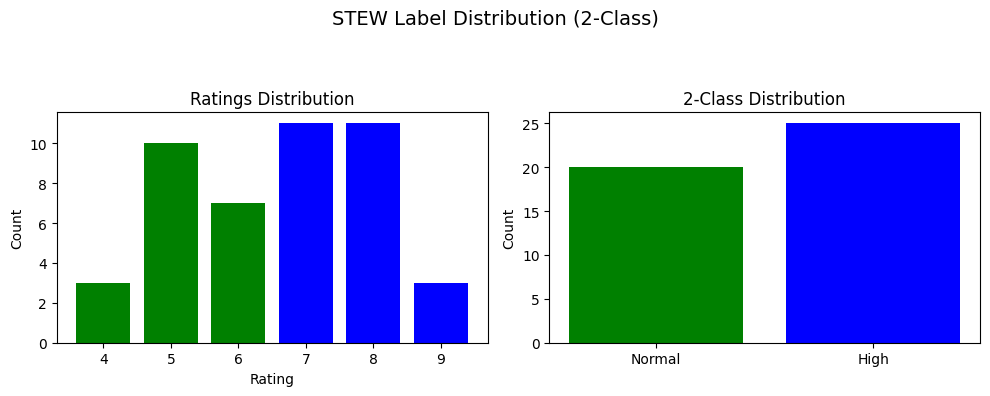

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# create figure
plt.figure(figsize=(10,4))

# ---- Plot 1: Ratings ----
plt.subplot(1,2,1)
values, counts = np.unique(ratings, return_counts=True)

colors = ['green' if v <= 6 else 'blue' for v in values]

plt.bar(values, counts, color=colors)
plt.title('Ratings Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')


# ---- Plot 2: 2-Class ----
plt.subplot(1,2,2)

labels = ['Normal', 'High']
counts2 = [
    np.sum(labels2 == 0),
    np.sum(labels2 == 1)
]

plt.bar(labels, counts2, color=['green', 'blue'])
plt.title('2-Class Distribution')
plt.ylabel('Count')


# ✅ Add overall title
plt.suptitle('STEW Label Distribution (2-Class)', fontsize=14)

# adjust layout so title fits
plt.tight_layout(rect=[0, 0, 1, 0.9])

# ✅ save image
plt.savefig('images/label_distribution.png', dpi=150)

# show plot
plt.show()

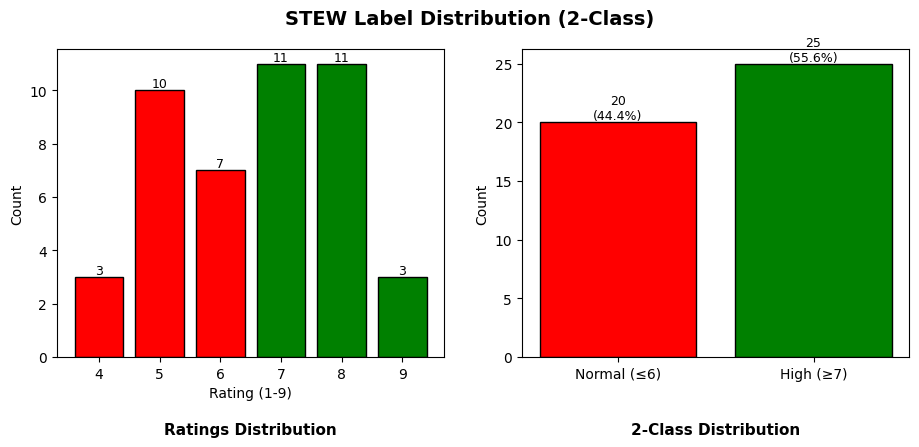

In [12]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(11,4))

# Plot - 1 : Ratings Distribution
plt.subplot(1,2,1)
values, counts = np.unique(ratings, return_counts=True)

colors = ['red' if v <= 6 else 'green' for v in values]

bars = plt.bar(values, counts, color=colors, edgecolor='black')

# add count labels
for bar, c in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, c,
             str(c), ha='center', va='bottom', fontsize=9)

plt.xlabel('Rating (1-9)')
plt.ylabel('Count')

# 👇 bottom heading
plt.text(0.5, -0.25, 'Ratings Distribution',
         transform=plt.gca().transAxes,
         ha='center', fontsize=11, fontweight='bold')


# Plot - 2 : 2 class labels Distribution
plt.subplot(1,2,2)

labels = ['Normal (≤6)', 'High (≥7)']
counts2 = [
    np.sum(labels2 == 0),
    np.sum(labels2 == 1)
]

bars2 = plt.bar(labels, counts2,
                color=['red', 'green'],
                edgecolor='black')

# add count + percentage
total = len(labels2)
for bar, c in zip(bars2, counts2):
    pct = (c / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2, c,
             f'{c}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=9)

plt.ylabel('Count')

#  bottom heading
plt.text(0.5, -0.25, '2-Class Distribution',
         transform=plt.gca().transAxes,
         ha='center', fontsize=11, fontweight='bold')


# title of plot
plt.suptitle('STEW Label Distribution (2-Class)', fontsize=14, fontweight='bold')

# correct spacing 
plt.tight_layout(rect=[0, 0, 0.1, 0.9])

# save plot
plt.savefig('images/label_distribution.png', dpi=150)

plt.show()

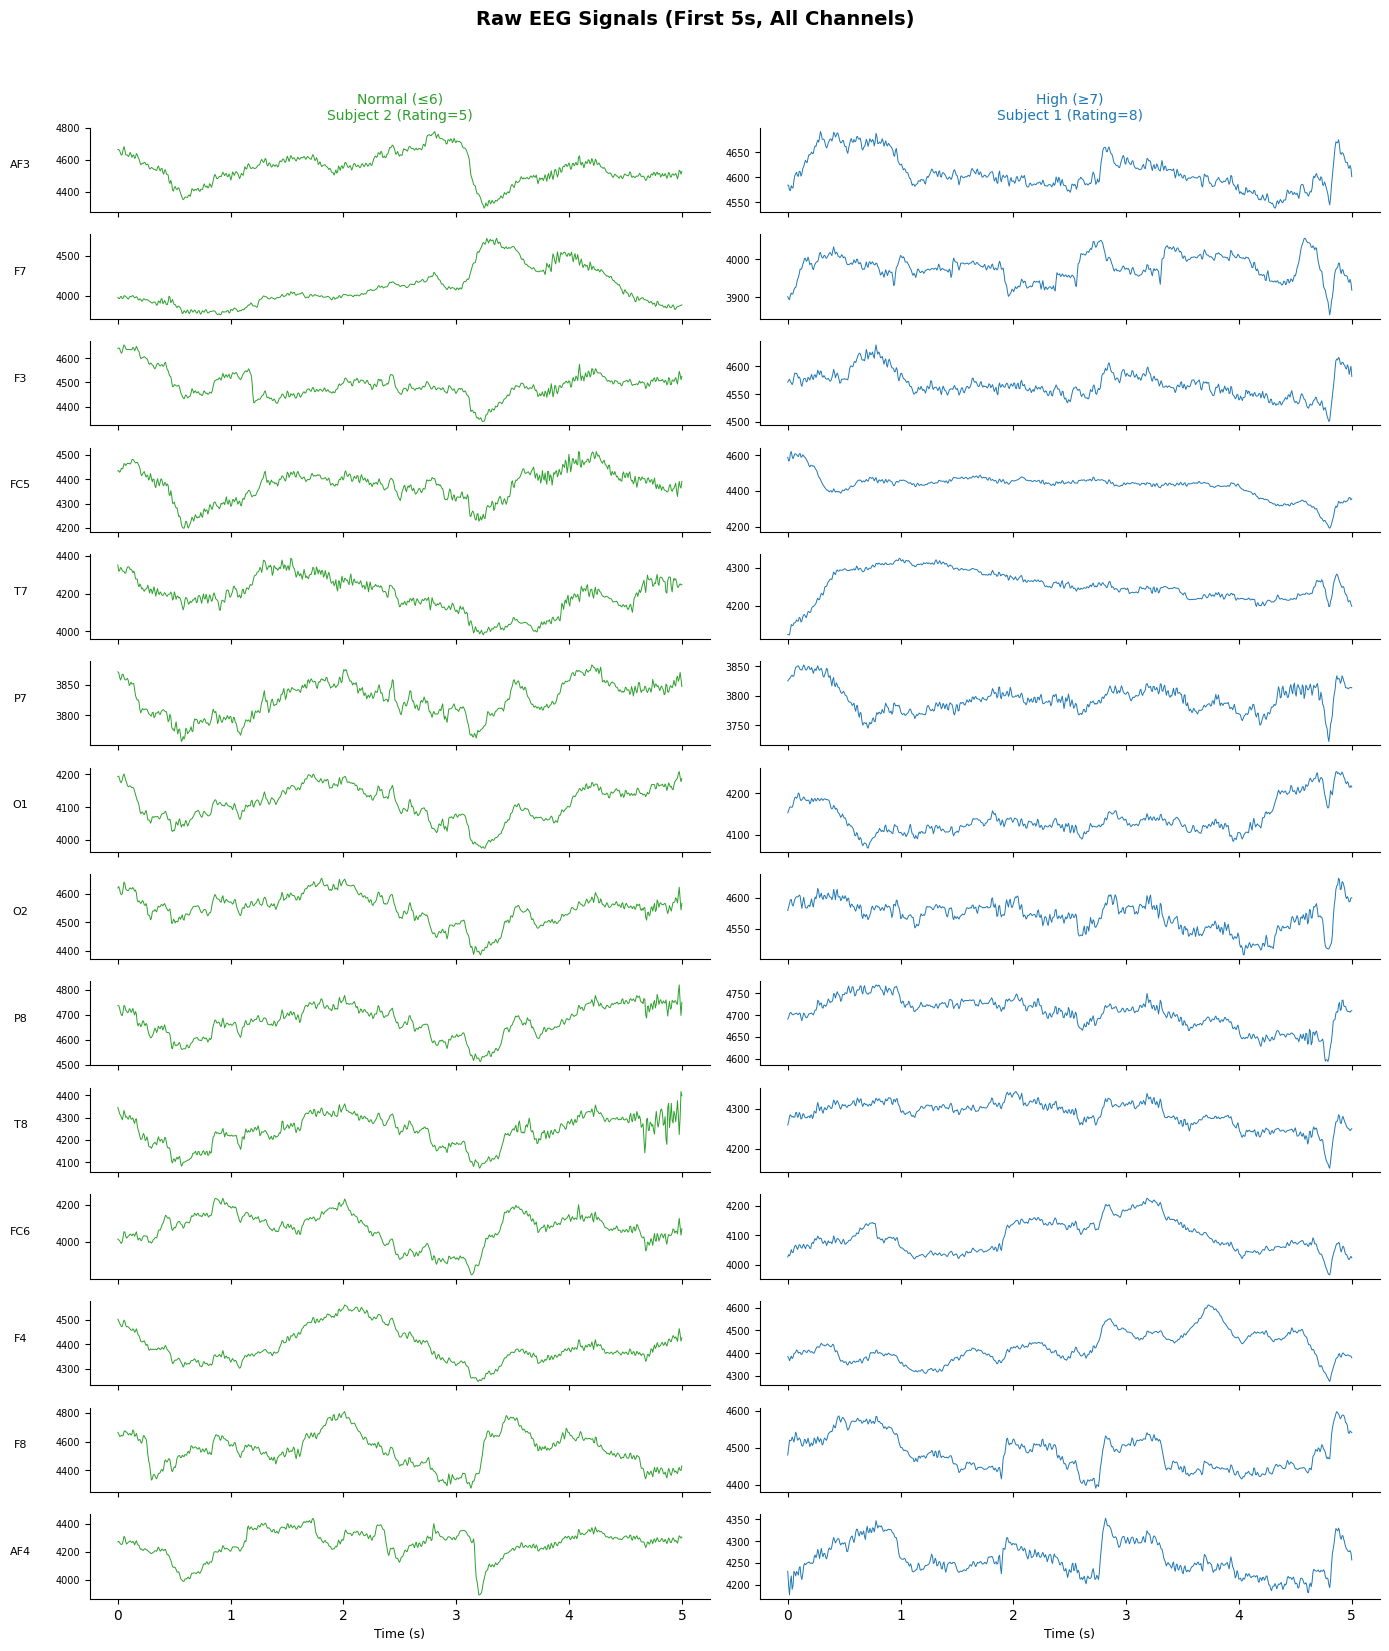

In [13]:
show_sec  = 5
show_samp = show_sec * frequency
t_axis = np.linspace(0, show_sec, show_samp)

# pick one subject per class
subj_normal = np.where(labels2 == 0)[0][0]
subj_high   = np.where(labels2 == 1)[0][0]

subjects_to_plot = [
    (subj_normal, 'Normal (≤6)', 'tab:green'),
    (subj_high,   'High (≥7)',   'tab:blue'),
]

fig, axes = plt.subplots(no_of_channels, 2,
                         figsize=(14, no_of_channels * 1.2),
                         sharex=True)

fig.suptitle(f'Raw EEG Signals (First {show_sec}s, All Channels)',
             fontsize=14, fontweight='bold')

for col, (subj_idx, title, color) in enumerate(subjects_to_plot):

    axes[0, col].set_title(
        f'{title}\nSubject {subj_idx+1} (Rating={ratings[subj_idx]:.0f})',
        fontsize=10, color=color
    )

    for ch in range(no_of_channels):
        sig = eeg[subj_idx, :show_samp, ch]

        axes[ch, col].plot(t_axis, sig, color=color, lw=0.7)

        # channel labels
        if col == 0:
            axes[ch, col].set_ylabel(channel_names[ch],
                                     fontsize=8, rotation=0, labelpad=25)

        # clean look
        axes[ch, col].spines[['top','right']].set_visible(False)
        axes[ch, col].tick_params(axis='y', labelsize=7)

        if ch == no_of_channels - 1:
            axes[ch, col].set_xlabel('Time (s)', fontsize=9)


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('images/raw_eeg_timeseries.png', dpi=120)
plt.show()

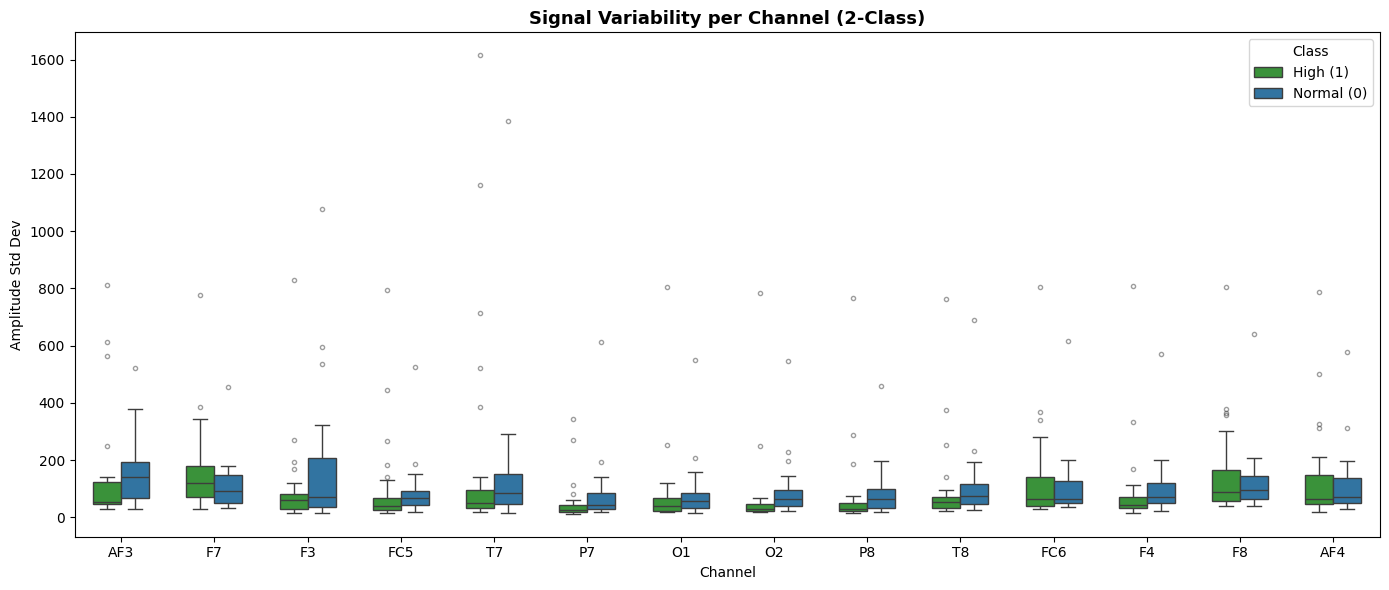

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# compute per-subject, per-channel statistics
ch_means = eeg.mean(axis=1)   # shape: (subjects, channels)
ch_stds  = eeg.std(axis=1)

# build dataframe for plotting
rows = []
for subj in range(no_of_subjects):
    for ch_idx, ch in enumerate(channel_names):
        rows.append({
            'Subject' : subj,
            'Channel' : ch,
            'Region'  : next((r for r, chs in region_map.items() if ch in chs), 'Other'),
            'Mean_Amp': ch_means[subj, ch_idx],
            'Std_Amp' : ch_stds[subj, ch_idx],
            'Label'   : labels2_str[subj],
        })

stats_df = pd.DataFrame(rows)


# plot signal variability per channel
plt.figure(figsize=(14,6))

sns.boxplot(
    data=stats_df,
    x='Channel',
    y='Std_Amp',
    hue='Label',
    palette=['tab:green', 'tab:blue'],
    width=0.6,
    flierprops=dict(marker='o', markersize=3, alpha=0.5)
)

# labels and title
plt.title('Signal Variability per Channel (2-Class)', fontsize=13, fontweight='bold')
plt.xlabel('Channel')
plt.ylabel('Amplitude Std Dev')
plt.legend(title='Class')

# layout and save figure
plt.tight_layout()
plt.savefig('images/channel_amplitude_stats.png', dpi=150)

plt.show()

In [15]:
from scipy.signal import welch
import numpy as np

n_bands = len(freq_bands)
bp_all = np.zeros((no_of_subjects, no_of_channels, n_bands), dtype=np.float32)

bands = list(freq_bands.values())

for s in range(no_of_subjects):
    for c in range(no_of_channels):

        # compute PSD once
        freqs, psd = welch(eeg[s, :, c], fs=frequency)

        # compute all bands from same PSD
        for b_idx, band in enumerate(bands):
            idx = (freqs >= band[0]) & (freqs <= band[1])
            bp_all[s, c, b_idx] = np.trapz(psd[idx], freqs[idx])

print(f'band power shape: {bp_all.shape}')

band power shape: (45, 14, 5)


In [16]:
plot_df = []

for b_idx, bname in enumerate(freq_bands.keys()):
    bp_avg = bp_all[:, :, b_idx].mean(axis=1)

    for i in range(no_of_subjects):
        plot_df.append({
            'Band': bname,
            'Power': bp_avg[i],
            'Class': labels2_str[i]
        })

plot_df = pd.DataFrame(plot_df)

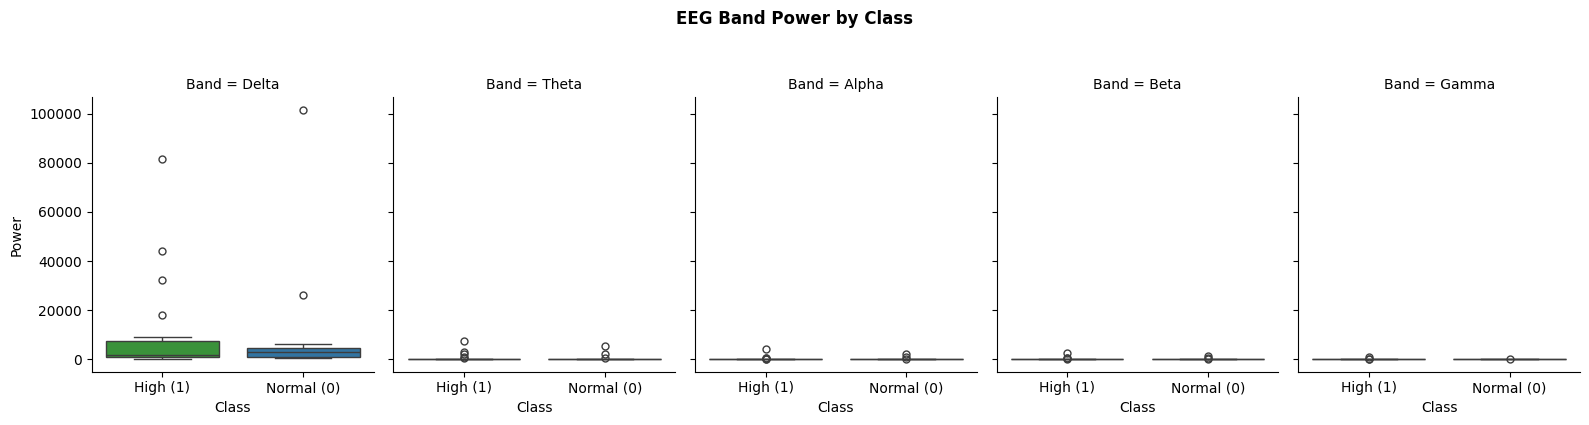

In [17]:
g = sns.catplot(
    data=plot_df,
    x='Class',
    y='Power',
    col='Band',
    kind='box',
    palette=['tab:green', 'tab:blue'],
    col_wrap=5,
    height=4,
    aspect=0.8
)

# title
g.fig.suptitle('EEG Band Power by Class', y=1.05, fontweight='bold')

# adjust layout
g.fig.tight_layout()

# save properly
g.fig.savefig('images/band_power_2class.png', dpi=150)

plt.show()

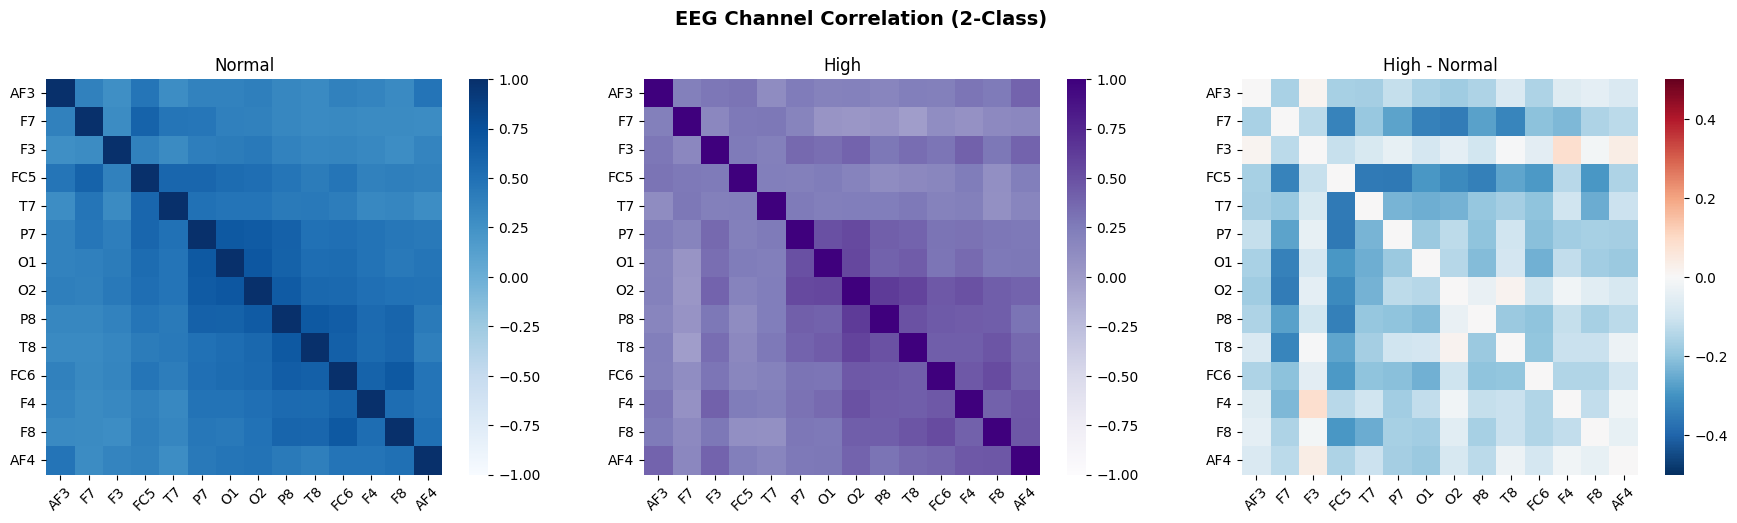

In [18]:
# Channel correlation

# compute average correlation matrix
def avg_corr_matrix(eeg_data, subject_indices):
    corrs = []
    for s in subject_indices:
        corrs.append(np.corrcoef(eeg_data[s].T))
    return np.mean(corrs, axis=0)


# indices for 2 classes
norm_idx = np.where(labels2 == 0)[0]
high_idx = np.where(labels2 == 1)[0]

# compute matrices
corr_norm = avg_corr_matrix(eeg, norm_idx)
corr_high = avg_corr_matrix(eeg, high_idx)
corr_diff = corr_high - corr_norm


# plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EEG Channel Correlation (2-Class)', fontsize=14, fontweight='bold')

plots = [
    (corr_norm, 'Normal', 'Blues', (-1, 1)),
    (corr_high, 'High', 'Purples', (-1, 1)),
    (corr_diff, 'High - Normal', 'RdBu_r', (-0.5, 0.5)),
]

for ax, (mat, title, cmap, vrange) in zip(axes, plots):
    sns.heatmap(
        mat,
        ax=ax,
        cmap=cmap,
        vmin=vrange[0],
        vmax=vrange[1],
        xticklabels=channel_names,
        yticklabels=channel_names,
        square=True,
        cbar=True
    )

    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('images/channel_correlations.png', dpi=150)

plt.show()

feature shape: (45, 70)


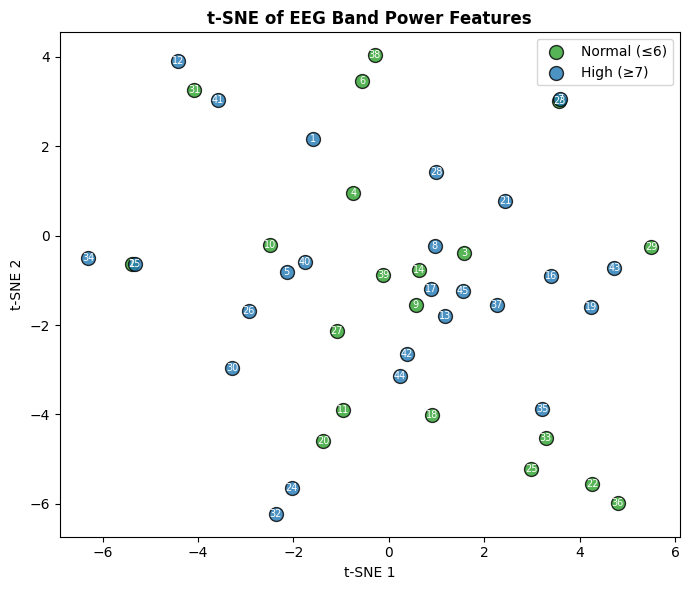

In [19]:
# t-SNE Visualization of EEG Band power features

# build feature matrix
features = bp_all.reshape(no_of_subjects, -1)
print(f'feature shape: {features.shape}')

# scale features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# t-SNE
perplexity = min(12, no_of_subjects // 3)

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    random_state=42,
    max_iter=1000,
    learning_rate='auto',
    init='pca'
)

tsne_xy = tsne.fit_transform(features_scaled)


# plot (2-class only)
plt.figure(figsize=(7,6))

for cls_val, label, color in [
    (0, 'Normal (≤6)', 'tab:green'),
    (1, 'High (≥7)',   'tab:blue')
]:
    mask = labels2 == cls_val

    plt.scatter(
        tsne_xy[mask, 0],
        tsne_xy[mask, 1],
        c=color,
        label=label,
        s=100,
        alpha=0.8,
        edgecolors='black'
    )

    # annotate subject id
    for i in np.where(mask)[0]:
        plt.text(tsne_xy[i,0], tsne_xy[i,1],
                 str(i+1), fontsize=7,
                 ha='center', va='center', color='white')


plt.title('t-SNE of EEG Band Power Features', fontweight='bold')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend()

plt.tight_layout()
plt.savefig('images/tsne_2class.png', dpi=150)

plt.show()